In [ ]:
# Synthetic EHR Cohort Study – Python Analysis

This notebook reproduces a logistic regression analysis using simulated
patient-level data generated in R. The objective is to estimate the
association between drug exposure and a binary outcome adjusting for age
and comorbidity score.

In [8]:
import pandas as pd
cohort = pd.read_csv(r"C:\Users\Santiago Mendez\Desktop\UoD\Fundamentals\synthetic-ehr-cohort-study\data\cohort_dataset.csv")
cohort.head()

,patient_id,age,sex,comorbidity_score,drug_exposure,follow_up_years,outcome,exposure_group
0,1,72.026346,Male,1,1,2.773404,0,Exposed
1,2,73.513592,Male,3,1,1.784143,1,Exposed
2,3,63.688360,Male,2,1,4.991120,0,Exposed
3,4,59.558034,Female,1,0,2.705983,0,Unexposed
4,5,72.270649,Female,1,1,3.658663,0,Exposed


In [5]:
import numpy as np
import statsmodels.api as sm
cohort.describe()
cohort["outcome"].mean()
X = cohort[["drug_exposure", "age", "comorbidity_score"]]
X = sm.add_constant(X)   # agrega intercepto
y = cohort["outcome"]

model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.601261
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                 9797
Model:                          Logit   Df Residuals:                     9793
Method:                           MLE   Df Model:                            3
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                  0.1141
Time:                        10:59:09   Log-Likelihood:                -5890.6
converged:                       True   LL-Null:                       -6649.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -3.1118      0.141    -22.075      0.000      -3.388      -2.835
drug_exp

In [6]:
params = result.params
conf = result.conf_int()
conf["OR"] = params
conf.columns = ["CI_lower", "CI_upper", "OR"]

or_table = np.exp(conf)
or_table

,CI_lower,CI_upper,OR
const,0.033775,0.058691,0.044523
drug_exposure,0.433464,0.519575,0.474570
age,1.027128,1.035223,1.031167
comorbidity_score,1.612232,1.724515,1.667429


In [7]:
or_table.to_csv("model_results_python.csv")

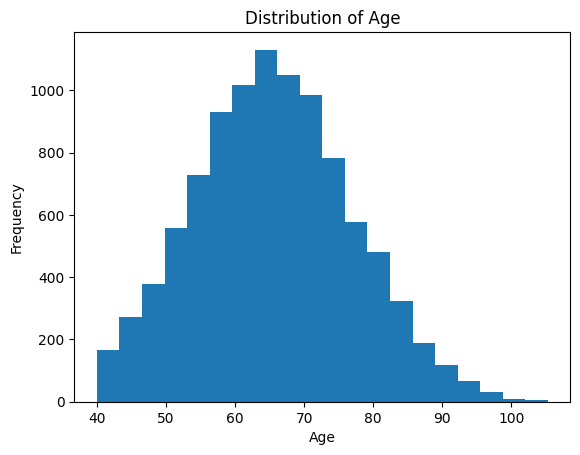

FileNotFoundError: [Errno 2] No such file or directory: 'figures/age_distribution.png'

<Figure size 640x480 with 0 Axes>

In [15]:
import matplotlib.pyplot as plt

plt.hist(cohort["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()
plt.savefig("figures/age_distribution.png")

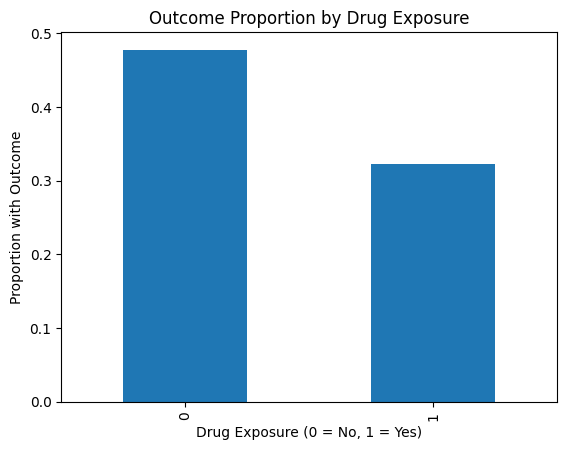

FileNotFoundError: [Errno 2] No such file or directory: 'figures/proportion_drug_exposure.png'

<Figure size 640x480 with 0 Axes>

In [14]:
outcome_by_exposure = cohort.groupby("drug_exposure")["outcome"].mean()
outcome_by_exposure
outcome_by_exposure.plot(kind="bar")
plt.xlabel("Drug Exposure (0 = No, 1 = Yes)")
plt.ylabel("Proportion with Outcome")
plt.title("Outcome Proportion by Drug Exposure")
plt.show()
plt.savefig("figures/proportion_drug_exposure.png")

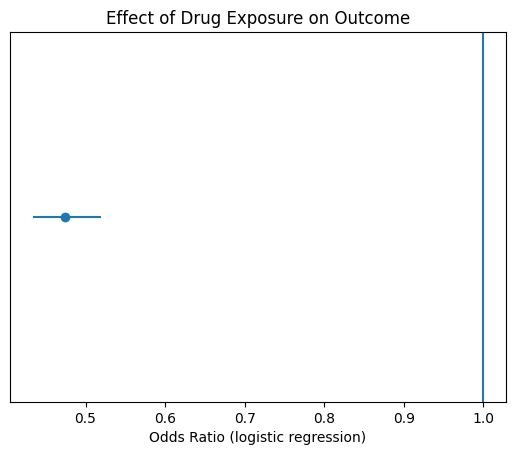

FileNotFoundError: [Errno 2] No such file or directory: 'figures/effect_drug_outcome.png'

<Figure size 640x480 with 0 Axes>

In [16]:
or_value = or_table.loc["drug_exposure", "OR"]
ci_low = or_table.loc["drug_exposure", "CI_lower"]
ci_high = or_table.loc["drug_exposure", "CI_upper"]

plt.errorbar(or_value, 0, 
             xerr=[[or_value - ci_low], [ci_high - or_value]], 
             fmt='o')
plt.axvline(1)
plt.yticks([])
plt.xlabel("Odds Ratio (logistic regression)")
plt.title("Effect of Drug Exposure on Outcome")
plt.show()
plt.savefig("figures/effect_drug_outcome.png")